# Experiment 1: Character Embeddings — Baseline vs Character-Conditioned GPT

Ablation study comparing two decoder-only GPT variants on TinyShakespeare:

| Model | Embedding formula |
|-------|------------------|
| **Baseline GPT** | `x = tok_emb(tokens) + pos_emb(positions)` |
| **Character-Conditioned GPT** | `x = tok_emb(tokens) + pos_emb(positions) + speaker_emb(character_id)` |

Both models share identical Transformer blocks, hyperparameters, and training data.

**Prerequisites**: Run notebook 2 first — needs `data/artifacts/bpe_tokenizer` and `data/{train,validation}.csv`.


## 1. Setup

In [1]:
from pathlib import Path
import sys, random, re, time, math, json, copy
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2Tokenizer
from IPython import get_ipython
from IPython.display import display, HTML

plt.style.use("seaborn-v0_8-darkgrid")


def notebook_tqdm(iterable, **kwargs):
    defaults = dict(mininterval=0.5, dynamic_ncols=True, file=sys.stdout)
    defaults.update(kwargs)
    shell = getattr(get_ipython(), "__class__", type("", (), {})).__name__
    if shell in ("ZMQInteractiveShell", "TerminalInteractiveShell"):
        from tqdm.std import tqdm
        return tqdm(iterable, **defaults)
    from tqdm.auto import tqdm
    return tqdm(iterable, **defaults)


cwd = Path.cwd()
if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(f"Could not locate 'data' directory from cwd: {cwd}")

DATA_DIR       = PROJECT_ROOT / "data"
ARTIFACTS_DIR  = DATA_DIR / "artifacts"
CHECKPOINT_DIR = ARTIFACTS_DIR / "model"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Project root : {PROJECT_ROOT}")
print(f"Device       : {device}")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


Project root : /projects/e32706/gwr4170/Text Generation/genre-story-generator
Device       : cuda


## 2. Data Loading

Load GPT-2 BPE tokenizer and raw CSV splits from notebook 2 artifacts.


In [2]:
tokenizer = GPT2Tokenizer.from_pretrained(str(ARTIFACTS_DIR / "bpe_tokenizer"))
tokenizer.model_max_length = int(1e9)
vocab_size = tokenizer.vocab_size

encode = lambda text: tokenizer.encode(text, add_special_tokens=False)
decode = tokenizer.decode

train_df  = pd.read_csv(DATA_DIR / "train.csv",      keep_default_na=False)
val_df    = pd.read_csv(DATA_DIR / "validation.csv", keep_default_na=False)
train_text = train_df["text"].str.cat(sep="\n")
val_text   = val_df["text"].str.cat(sep="\n")

print(f"vocab      : {vocab_size:,}")
print(f"train chars: {len(train_text):,} | val chars: {len(val_text):,}")


vocab      : 50,257
train chars: 1,003,854 | val chars: 55,770


## 3. Character-Wise Data Construction

Parse `SPEAKER:\n{dialogue}` turns. Each token in a turn gets the exact speaker ID.
Non-dialogue text (stage directions, narration) is excluded.


In [3]:
SPEAKER_LINE = re.compile(r"^([A-Z][A-Z ]+):", re.MULTILINE)
TURN_PATTERN = re.compile(
    r"^([A-Z][A-Z ]+):\n(.*?)(?=\n[A-Z][A-Z ]+:|\Z)",
    re.MULTILINE | re.DOTALL,
)


def parse_speaker_turns(text: str) -> list[tuple[str, str]]:
    return TURN_PATTERN.findall(text)


def format_conditioned_turn(speaker: str, dialogue: str) -> str:
    return f"{speaker}:\n{dialogue.strip()}\n\n"


def build_speaker_corpora(text: str) -> dict[str, str]:
    corpora: dict[str, str] = {}
    for speaker, dialogue in parse_speaker_turns(text):
        corpora.setdefault(speaker, "")
        corpora[speaker] += format_conditioned_turn(speaker, dialogue)
    return corpora


def build_speaker_to_id(text: str) -> dict[str, int]:
    """ID 0 reserved for unknown."""
    speakers = sorted(set(SPEAKER_LINE.findall(text)))
    return {name: idx + 1 for idx, name in enumerate(speakers)}


def build_conditioned_tensors(
    text: str,
    speaker_to_id: dict[str, int],
    encode_fn,
) -> tuple[torch.Tensor, torch.Tensor]:
    all_ids: list[int] = []
    all_speaker_ids: list[int] = []
    for speaker, dialogue in parse_speaker_turns(text):
        turn_text = format_conditioned_turn(speaker, dialogue)
        turn_ids  = encode_fn(turn_text)
        sid = speaker_to_id.get(speaker, 0)
        all_ids.extend(turn_ids)
        all_speaker_ids.extend([sid] * len(turn_ids))
    return (
        torch.tensor(all_ids,        dtype=torch.long),
        torch.tensor(all_speaker_ids, dtype=torch.long),
    )


speaker_to_id  = build_speaker_to_id(train_text)
num_characters = len(speaker_to_id) + 1          # +1 for ID-0 unknown
id_to_speaker  = {v: k for k, v in speaker_to_id.items()}
id_to_speaker[0] = "<UNKNOWN>"

train_turns      = parse_speaker_turns(train_text)
val_turns        = parse_speaker_turns(val_text)
speaker_corpora  = build_speaker_corpora(train_text)

print(f"Unique speakers (train)        : {len(speaker_to_id)}")
print(f"Total character IDs (incl. unk): {num_characters}")
print(f"Parsed turns — train: {len(train_turns):,} | val: {len(val_turns):,}")
print(f"Sample speakers: {list(speaker_to_id.items())[:10]}")
print(f"\nSample formatted turn:\n{format_conditioned_turn(*train_turns[0])[:200]}...")


Unique speakers (train)        : 154
Total character IDs (incl. unk): 155
Parsed turns — train: 5,237 | val: 413
Sample speakers: [('ABHORSON', 1), ('ABRAHAM', 2), ('ALL', 3), ('ANGELO', 4), ('ANOTHER', 5), ('ANTIGONUS', 6), ('ARCHBISHOP OF YORK', 7), ('ARCHIDAMUS', 8), ('AUFIDIUS', 9), ('AUTOLYCUS', 10)]

Sample formatted turn:
MENENIUS:
What work's, my countrymen, in hand? where go you
With bats and clubs? The matter? speak, I pray you.

First Citizen:
Our business is not unknown to the senate; they have
had inkling this fo...


In [4]:
print("Building train conditioned tensors...")
train_ids, train_speaker_ids = build_conditioned_tensors(train_text, speaker_to_id, encode)
print(f"train_ids: {train_ids.shape} | train_speaker_ids: {train_speaker_ids.shape}")

print("Building val conditioned tensors...")
val_ids, val_speaker_ids = build_conditioned_tensors(val_text, speaker_to_id, encode)
print(f"val_ids:   {val_ids.shape}   | val_speaker_ids:   {val_speaker_ids.shape}")

# Coverage stats
train_labeled = (train_speaker_ids > 0).sum().item()
val_labeled   = (val_speaker_ids   > 0).sum().item()
print(f"\nTrain tokens with label: {train_labeled:,}/{len(train_speaker_ids):,} ({100*train_labeled/len(train_speaker_ids):.1f}%)")
print(f"Val   tokens with label: {val_labeled:,}/{len(val_speaker_ids):,} ({100*val_labeled/len(val_speaker_ids):.1f}%)")

# ── Unknown-ID analysis for val set ──────────────────────────────────────────
val_unknown = (val_speaker_ids == 0).sum().item()
print(f"\nVal tokens with unknown ID (id=0): {val_unknown:,} ({100*val_unknown/len(val_speaker_ids):.1f}%)")
print("  → These tokens degrade conditioned model's val signal; note in analysis.")

# Per-character token counts
speaker_token_counts = {sp: len(encode(corpus)) for sp, corpus in speaker_corpora.items()}
top15 = sorted(speaker_token_counts.items(), key=lambda x: -x[1])[:15]
print("\nTop 15 speakers by token count (train corpora):")
for speaker, count in top15:
    sid = speaker_to_id.get(speaker, 0)
    print(f"  {speaker:>25s} (id={sid:3d}): {count:>8,} tokens")

# Tensor-level cross-check
train_speaker_counts = Counter(train_speaker_ids.tolist())
print("\nTop 15 by tensor counts:")
for sid, count in train_speaker_counts.most_common(15):
    print(f"  {id_to_speaker.get(sid,'?'):>25s} (id={sid:3d}): {count:>8,} tokens")


Building train conditioned tensors...
train_ids: torch.Size([296180]) | train_speaker_ids: torch.Size([296180])
Building val conditioned tensors...
val_ids:   torch.Size([17654])   | val_speaker_ids:   torch.Size([17654])

Train tokens with label: 296,180/296,180 (100.0%)
Val   tokens with label: 17,121/17,654 (97.0%)

Val tokens with unknown ID (id=0): 533 (3.0%)
  → These tokens degrade conditioned model's val signal; note in analysis.

Top 15 speakers by token count (train corpora):
                 GLOUCESTER (id= 65):   13,313 tokens
             DUKE VINCENTIO (id= 47):   12,237 tokens
            KING RICHARD II (id= 86):    9,915 tokens
                   MENENIUS (id=107):    9,699 tokens
                 CORIOLANUS (id= 36):    9,330 tokens
                     JULIET (id= 81):    9,087 tokens
                    LEONTES (id= 94):    8,841 tokens
                      ROMEO (id=134):    8,583 tokens
                  AUTOLYCUS (id= 10):    7,727 tokens
             QUEEN MARG

## 4. Model Architecture

Shared Transformer blocks + two GPT variants:
- **`GPTBaseline`** — `token_emb + pos_emb`
- **`GPTCharacterConditioned`** — adds `speaker_emb(character_id)`


In [5]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = d_model // n_heads
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj  = nn.Linear(d_model, d_model)
        self.attn_dropout  = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self._causal_cache = None

    def _causal_mask(self, size: int, device: torch.device):
        if self._causal_cache is None or self._causal_cache.size(-1) < size:
            self._causal_cache = torch.tril(
                torch.ones(size, size, device=device)
            ).view(1, 1, size, size)
        return self._causal_cache[:, :, :size, :size]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.size()
        q, k, v = self.qkv_proj(x).chunk(3, dim=-1)

        def rh(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = rh(q), rh(k), rh(v)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self._causal_mask(T, x.device)[:, :, :T, :T] == 0, float("-inf"))
        att = self.attn_dropout(F.softmax(att, dim=-1))
        y   = att @ v
        y   = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.out_proj(y))


class FeedForward(nn.Sequential):
    def __init__(self, d_model: int, d_ff_mult: int, dropout: float):
        super().__init__(
            nn.Linear(d_model, d_ff_mult * d_model),
            nn.GELU(),
            nn.Linear(d_ff_mult * d_model, d_model),
            nn.Dropout(dropout),
        )


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff_mult: int, dropout: float):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.ln2  = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ff   = FeedForward(d_model, d_ff_mult, dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


In [6]:
def _nucleus_sample(logits: torch.Tensor, top_k: int, top_p: float) -> torch.Tensor:
    """
    Apply top-k then nucleus (top-p) filtering to logits.
    Fixed: scatters pruned values back into the original logit tensor correctly.
    """
    if top_k > 0:
        k = min(top_k, logits.size(-1))
        thresh = torch.topk(logits, k, dim=-1).values[:, [-1]]
        logits = logits.masked_fill(logits < thresh, float("-inf"))

    if top_p < 1.0:
        sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
        cum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
        # shift right so we keep the token that pushes over the threshold
        remove = (cum_probs - F.softmax(sorted_logits, dim=-1)) >= top_p
        sorted_logits = sorted_logits.masked_fill(remove, float("-inf"))
        # scatter pruned sorted logits back to original vocab ordering
        logits = torch.full_like(logits, float("-inf"))
        logits.scatter_(1, sorted_idx, sorted_logits)

    return logits


class GPTBaseline(nn.Module):
    """Standard decoder-only GPT: token_emb + pos_emb."""

    def __init__(self, vocab_size: int, config: dict):
        super().__init__()
        d = config
        self.block_size      = d["block_size"]
        self.token_embedding = nn.Embedding(vocab_size, d["d_model"])
        self.pos_embedding   = nn.Embedding(d["block_size"], d["d_model"])
        self.drop    = nn.Dropout(d["dropout"])
        self.blocks  = nn.ModuleList([
            TransformerBlock(d["d_model"], d["n_heads"], d.get("d_ff", 4), d["dropout"])
            for _ in range(d["n_layers"])
        ])
        self.ln_f = nn.LayerNorm(d["d_model"])
        self.head = nn.Linear(d["d_model"], vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.block_size
        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x   = self.drop(self.token_embedding(idx) + self.pos_embedding(pos))
        for block in self.blocks: x = block(x)
        logits = self.head(self.ln_f(x))
        loss   = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T)) if targets is not None else None
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=0, top_p=1.0):
        self.eval()
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -self.block_size:])
            logits     = _nucleus_sample(logits[:, -1, :] / max(temperature, 1e-8), top_k, top_p)
            idx = torch.cat([idx, torch.multinomial(F.softmax(logits, -1), 1)], dim=1)
        return idx


class GPTCharacterConditioned(nn.Module):
    """Character-conditioned GPT: token_emb + pos_emb + speaker_emb."""

    def __init__(self, vocab_size: int, num_characters: int, config: dict):
        super().__init__()
        d = config
        self.block_size       = d["block_size"]
        self.token_embedding  = nn.Embedding(vocab_size,    d["d_model"])
        self.pos_embedding    = nn.Embedding(d["block_size"], d["d_model"])
        self.speaker_embedding = nn.Embedding(num_characters, d["d_model"])
        self.drop    = nn.Dropout(d["dropout"])
        self.blocks  = nn.ModuleList([
            TransformerBlock(d["d_model"], d["n_heads"], d.get("d_ff", 4), d["dropout"])
            for _ in range(d["n_layers"])
        ])
        self.ln_f = nn.LayerNorm(d["d_model"])
        self.head = nn.Linear(d["d_model"], vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, idx, targets=None, character_ids=None):
        B, T = idx.size()
        assert T <= self.block_size
        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x   = self.token_embedding(idx) + self.pos_embedding(pos)
        if character_ids is not None:
            x = x + self.speaker_embedding(character_ids)
        x = self.drop(x)
        for block in self.blocks: x = block(x)
        logits = self.head(self.ln_f(x))
        loss   = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T)) if targets is not None else None
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, character_id=0, temperature=1.0, top_k=0, top_p=1.0):
        """
        Generate conditioned on a fixed character_id broadcast across context.
        Note: broadcasting one ID over the full window is a simplification —
        the embedding injects consistent speaker identity, but prompt tokens from
        a different speaker will receive conflicting conditioning signal.
        """
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            B, T     = idx_cond.size()
            char_ids = torch.full((B, T), character_id, dtype=torch.long, device=idx.device)
            logits, _ = self(idx_cond, character_ids=char_ids)
            logits     = _nucleus_sample(logits[:, -1, :] / max(temperature, 1e-8), top_k, top_p)
            idx = torch.cat([idx, torch.multinomial(F.softmax(logits, -1), 1)], dim=1)
        return idx


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


## 5. Experiment Configuration

In [23]:
QUICK_RUN = False  # True → smoke test (~100 steps)

EXPERIMENT_CONFIG = {
    "seed"                   : 42,
    "block_size"             : 256,
    "batch_size"             : 64,
    "n_layers"               : 7,
    "d_model"                : 256,
    "n_heads"                : 8,
    "d_ff"                   : 4,
    "dropout"                : 0.16477808070586997,
    "learning_rate"          : 0.00013716108015042092,
    "weight_decay"           : 0.1,
    "betas"                  : (0.9, 0.95),
    "warmup_steps"           : 0,
    "min_lr_ratio"           : 0.1,
    "grad_clip"              : 1.0,
    "max_steps"              : 5000,
    "eval_interval"          : 500,
    "eval_batches"           : 200,
    "early_stopping_patience": 3,   # None to disable
    "use_amp"                : True,
}

if QUICK_RUN:
    EXPERIMENT_CONFIG.update({
        "max_steps": 100, "eval_interval": 20,
        "warmup_steps": 10, "eval_batches": 10,
        "early_stopping_patience": 3,
    })

if device != "cuda":
    EXPERIMENT_CONFIG["use_amp"] = False

EXPERIMENT_CONFIG["min_lr"] = (
    float(EXPERIMENT_CONFIG["learning_rate"]) * float(EXPERIMENT_CONFIG["min_lr_ratio"])
)

_bp = GPTBaseline(vocab_size, EXPERIMENT_CONFIG)
_cp = GPTCharacterConditioned(vocab_size, num_characters, EXPERIMENT_CONFIG)
baseline_params    = count_parameters(_bp)
conditioned_params = count_parameters(_cp)
speaker_emb_params = num_characters * EXPERIMENT_CONFIG["d_model"]
del _bp, _cp

print("=== Config ===")
for k in ["n_layers","d_model","n_heads","block_size","dropout","learning_rate","max_steps","early_stopping_patience"]:
    print(f"  {k}: {EXPERIMENT_CONFIG[k]}")
print(f"\n=== Parameter Counts ===")
print(f"  Baseline             : {baseline_params:>12,}")
print(f"  Character-Conditioned: {conditioned_params:>12,}")
print(f"  Speaker emb overhead : {speaker_emb_params:>12,}  ({100*speaker_emb_params/baseline_params:.2f}% of baseline)")
print(f"  Num characters       : {num_characters}")
print(f"  QUICK_RUN            : {QUICK_RUN}")


=== Config ===
  n_layers: 7
  d_model: 256
  n_heads: 8
  block_size: 256
  dropout: 0.16477808070586997
  learning_rate: 0.00013716108015042092
  max_steps: 5000
  early_stopping_patience: 3

=== Parameter Counts ===
  Baseline             :   31,325,952
  Character-Conditioned:   31,365,632
  Speaker emb overhead :       39,680  (0.13% of baseline)
  Num characters       : 155
  QUICK_RUN            : False


## 6. Data Batching

Each training run creates its own seeded generator — both models see the identical data sequence.


In [24]:
def get_batch_baseline(split, batch_size, block_size, device=device, generator=None):
    data = train_ids if split == "train" else val_ids
    gen  = generator or torch.Generator().manual_seed(0)
    ix   = torch.randint(0, len(data) - block_size - 1, (batch_size,), generator=gen)
    rows = ix.unsqueeze(1) + torch.arange(block_size)
    return data[rows].to(device), data[rows + 1].to(device)


def get_batch_conditioned(split, batch_size, block_size, device=device, generator=None):
    data = train_ids        if split == "train" else val_ids
    spk  = train_speaker_ids if split == "train" else val_speaker_ids
    gen  = generator or torch.Generator().manual_seed(0)
    ix   = torch.randint(0, len(data) - block_size - 1, (batch_size,), generator=gen)
    rows = ix.unsqueeze(1) + torch.arange(block_size)
    return data[rows].to(device), data[rows + 1].to(device), spk[rows].to(device)


# Smoke test
_xb, _yb = get_batch_baseline("train", 4, EXPERIMENT_CONFIG["block_size"], "cpu",
                               torch.Generator().manual_seed(0))
_xc, _yc, _sc = get_batch_conditioned("train", 4, EXPERIMENT_CONFIG["block_size"], "cpu",
                                       torch.Generator().manual_seed(0))
assert _xb.shape == (4, EXPERIMENT_CONFIG["block_size"])
assert _xc.shape == _sc.shape == (4, EXPERIMENT_CONFIG["block_size"])
print("Batch smoke-test OK")
del _xb, _yb, _xc, _yc, _sc


Batch smoke-test OK


## 7. Training Infrastructure

In [25]:
try:
    _LRBase = torch.optim.lr_scheduler.LRScheduler
except AttributeError:
    _LRBase = torch.optim.lr_scheduler._LRScheduler


class CosineWarmupScheduler(_LRBase):
    def __init__(self, optimizer, warmup_steps, max_steps, min_lr=0.0, last_epoch=-1):
        self.warmup_steps = max(warmup_steps, 1)
        self.max_steps    = max(max_steps, warmup_steps + 1)   # guard div-by-zero
        self.min_lr       = min_lr
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = self.last_epoch + 1
        if step < self.warmup_steps:
            scale = step / self.warmup_steps
        else:
            progress = min((step - self.warmup_steps) / (self.max_steps - self.warmup_steps), 1.0)
            scale    = 0.5 * (1.0 + math.cos(math.pi * progress))
        return [self.min_lr + (base - self.min_lr) * scale for base in self.base_lrs]


def autocast_ctx(config):
    enabled = bool(config.get("use_amp")) and device == "cuda"
    dtype   = "cuda" if device == "cuda" else "cpu"
    return torch.amp.autocast(device_type=dtype, enabled=enabled)


def create_optimizer_and_scheduler(model, config):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad: continue
        if p.dim() >= 2 and "bias" not in name and "norm" not in name.lower():
            decay.append(p)
        else:
            no_decay.append(p)
    optimizer = torch.optim.AdamW(
        [{"params": decay, "weight_decay": config["weight_decay"]},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=config["learning_rate"], betas=tuple(config.get("betas", (0.9, 0.95))),
    )
    scheduler = CosineWarmupScheduler(
        optimizer, config["warmup_steps"], config["max_steps"], config["min_lr"]
    )
    return optimizer, scheduler


In [26]:
@torch.no_grad()
def estimate_loss(model, model_type, config, seed_offset=0):
    """
    Evaluate on both splits using fresh, reproducible generators.
    Each call uses its own generators so the eval sequence is stable
    regardless of training state.
    """
    model.eval()
    out = {}
    for split in ("train", "val"):
        gen    = torch.Generator().manual_seed(config["seed"] + seed_offset + (0 if split == "train" else 1))
        losses = []
        for _ in range(config["eval_batches"]):
            if model_type == "conditioned":
                x, y, s = get_batch_conditioned(split, config["batch_size"], config["block_size"], device, gen)
                with autocast_ctx(config):
                    _, loss = model(x, y, character_ids=s)
            else:
                x, y = get_batch_baseline(split, config["batch_size"], config["block_size"], device, gen)
                with autocast_ctx(config):
                    _, loss = model(x, y)
            losses.append(loss.item())
        avg = float(np.mean(losses))
        out[split] = {"loss": avg, "ppl": math.exp(avg)}
    model.train()
    return out


def save_checkpoint(model, config, extra, path):
    torch.save({
        "model" : {k: v.cpu().clone() for k, v in model.state_dict().items()},
        "config": copy.deepcopy(config),
        "extra" : extra,
    }, path)


In [27]:
def train_model(model, model_type, optimizer, scheduler, scaler, config, ckpt_path):
    """Unified training loop. model_type: 'baseline' | 'conditioned'"""
    max_steps     = config["max_steps"]
    eval_interval = config["eval_interval"]
    patience      = config.get("early_stopping_patience")
    label         = "Baseline" if model_type == "baseline" else "Conditioned"

    best_val_loss = float("inf")
    best_val_ppl  = float("inf")
    best_step     = 0
    patience_ctr  = 0
    stopped_early = False
    history       = {"step": [], "train_loss": [], "val_loss": [],
                     "train_ppl": [], "val_ppl": [], "lr": []}

    # Per-run seeded generator — both models see the exact same data sequence
    t_gen = torch.Generator().manual_seed(config["seed"])

    model.train()
    t0 = time.time()

    # Step-0 eval
    m0 = estimate_loss(model, model_type, config)
    print(f"[{label}] step 0 (init) | val {m0['val']['loss']:.4f} (ppl {m0['val']['ppl']:.1f}) | "
          f"train {m0['train']['loss']:.4f}")

    pbar = notebook_tqdm(range(max_steps), desc=f"{label}", unit="step")
    completed_step = 0

    for step in pbar:
        optimizer.zero_grad(set_to_none=True)

        if model_type == "conditioned":
            x, y, s = get_batch_conditioned("train", config["batch_size"], config["block_size"], device, t_gen)
            with autocast_ctx(config):
                _, loss = model(x, y, character_ids=s)
        else:
            x, y = get_batch_baseline("train", config["batch_size"], config["block_size"], device, t_gen)
            with autocast_ctx(config):
                _, loss = model(x, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.get("grad_clip", 1.0))
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        completed_step = step + 1
        lr = optimizer.param_groups[0]["lr"]

        if step % 10 == 0:
            pbar.set_postfix(loss=f"{loss.item():.3f}", lr=f"{lr:.1e}", best=f"{best_val_loss:.3f}")

        if completed_step % eval_interval == 0 or step == max_steps - 1:
            metrics = estimate_loss(model, model_type, config, seed_offset=completed_step)
            tl, vl  = metrics["train"]["loss"], metrics["val"]["loss"]
            history["step"].append(completed_step)
            history["train_loss"].append(tl)
            history["val_loss"].append(vl)
            history["train_ppl"].append(metrics["train"]["ppl"])
            history["val_ppl"].append(metrics["val"]["ppl"])
            history["lr"].append(lr)

            if vl < best_val_loss:
                best_val_loss = vl
                best_val_ppl  = metrics["val"]["ppl"]
                best_step     = completed_step
                patience_ctr  = 0
                save_checkpoint(model, config, {"best_step": best_step, "model_type": model_type}, ckpt_path)
                tag = f"NEW BEST → saved {ckpt_path.name}"
            else:
                patience_ctr += 1
                tag = f"patience {patience_ctr}/{patience}"

            pbar.write(f"  [{label}] step {completed_step:5d}: val {vl:.4f} (ppl {metrics['val']['ppl']:.1f}) | "
                       f"train {tl:.4f} | {tag}")

            if patience is not None and patience_ctr >= patience:
                stopped_early = True
                pbar.write(f"  [{label}] early stopping at step {completed_step}")
                break

    elapsed = time.time() - t0
    stop_note = " (early stopped)" if stopped_early else ""
    print(f"\n{label} done in {elapsed:.1f}s{stop_note} | "
          f"steps {completed_step}/{max_steps} | "
          f"best val {best_val_loss:.4f} (ppl {best_val_ppl:.1f}) @ step {best_step}")

    return {
        "model_type"   : model_type,
        "best_val_loss": best_val_loss,
        "best_val_ppl" : best_val_ppl,
        "best_step"    : best_step,
        "total_steps"  : completed_step,
        "stopped_early": stopped_early,
        "elapsed_s"    : round(elapsed, 2),
        "history"      : history,
    }


## 8. Run Experiments

In [28]:
# ── Baseline ─────────────────────────────────────────────────────────────────
print("=" * 60)
print("TRAINING BASELINE GPT")
print("=" * 60)

set_seed(EXPERIMENT_CONFIG["seed"])
baseline_model = GPTBaseline(vocab_size, EXPERIMENT_CONFIG).to(device)
baseline_opt, baseline_sched = create_optimizer_and_scheduler(baseline_model, EXPERIMENT_CONFIG)
baseline_scaler = torch.amp.GradScaler(enabled=bool(EXPERIMENT_CONFIG.get("use_amp")) and device == "cuda")

baseline_ckpt = CHECKPOINT_DIR / "gpt_baseline_experiment.pt"
baseline_result = train_model(
    baseline_model, "baseline",
    baseline_opt, baseline_sched, baseline_scaler,
    EXPERIMENT_CONFIG, baseline_ckpt,
)


TRAINING BASELINE GPT
[Baseline] step 0 (init) | val 10.8532 (ppl 51701.0) | train 10.8547
  [Baseline] step   500: val 4.8848 (ppl 132.3) | train 4.3661 | NEW BEST → saved gpt_baseline_experiment.pt
  [Baseline] step  1000: val 4.6625 (ppl 105.9) | train 3.8232 | NEW BEST → saved gpt_baseline_experiment.pt
  [Baseline] step  1500: val 4.5691 (ppl 96.5) | train 3.4577 | NEW BEST → saved gpt_baseline_experiment.pt
  [Baseline] step  2000: val 4.5947 (ppl 99.0) | train 3.1287 | patience 1/3                       
  [Baseline] step  2500: val 4.6938 (ppl 109.3) | train 2.8436 | patience 2/3                      
  [Baseline] step  3000: val 4.8001 (ppl 121.5) | train 2.6034 | patience 3/3                      
  [Baseline] early stopping at step 3000                                                           
Baseline:  60%|█████▉    | 2999/5000 [02:48<01:52, 17.81step/s, best=4.569, loss=2.906, lr=5.7e-05]

Baseline done in 174.9s (early stopped) | steps 3000/5000 | best val 4.5691 (ppl 9

In [29]:
# ── Character-Conditioned ─────────────────────────────────────────────────────
print("=" * 60)
print("TRAINING CHARACTER-CONDITIONED GPT")
print("=" * 60)

set_seed(EXPERIMENT_CONFIG["seed"])
conditioned_model = GPTCharacterConditioned(vocab_size, num_characters, EXPERIMENT_CONFIG).to(device)
conditioned_opt, conditioned_sched = create_optimizer_and_scheduler(conditioned_model, EXPERIMENT_CONFIG)
conditioned_scaler = torch.amp.GradScaler(enabled=bool(EXPERIMENT_CONFIG.get("use_amp")) and device == "cuda")

conditioned_ckpt = CHECKPOINT_DIR / "gpt_conditioned_experiment.pt"
conditioned_result = train_model(
    conditioned_model, "conditioned",
    conditioned_opt, conditioned_sched, conditioned_scaler,
    EXPERIMENT_CONFIG, conditioned_ckpt,
)


TRAINING CHARACTER-CONDITIONED GPT
[Conditioned] step 0 (init) | val 10.9064 (ppl 54524.9) | train 10.8952
  [Conditioned] step   500: val 4.8629 (ppl 129.4) | train 4.3594 | NEW BEST → saved gpt_conditioned_experiment.pt
  [Conditioned] step  1000: val 4.6004 (ppl 99.5) | train 3.7675 | NEW BEST → saved gpt_conditioned_experiment.pt
  [Conditioned] step  1500: val 4.5416 (ppl 93.8) | train 3.3650 | NEW BEST → saved gpt_conditioned_experiment.pt
  [Conditioned] step  2000: val 4.6009 (ppl 99.6) | train 3.0197 | patience 1/3                       
  [Conditioned] step  2500: val 4.6994 (ppl 109.9) | train 2.7179 | patience 2/3                      
  [Conditioned] step  3000: val 4.8324 (ppl 125.5) | train 2.4645 | patience 3/3                      
  [Conditioned] early stopping at step 3000                                                           
Conditioned:  60%|█████▉    | 2999/5000 [02:49<01:53, 17.66step/s, best=4.542, loss=2.765, lr=5.7e-05]

Conditioned done in 176.3s (early 

## 9. Quantitative Comparison

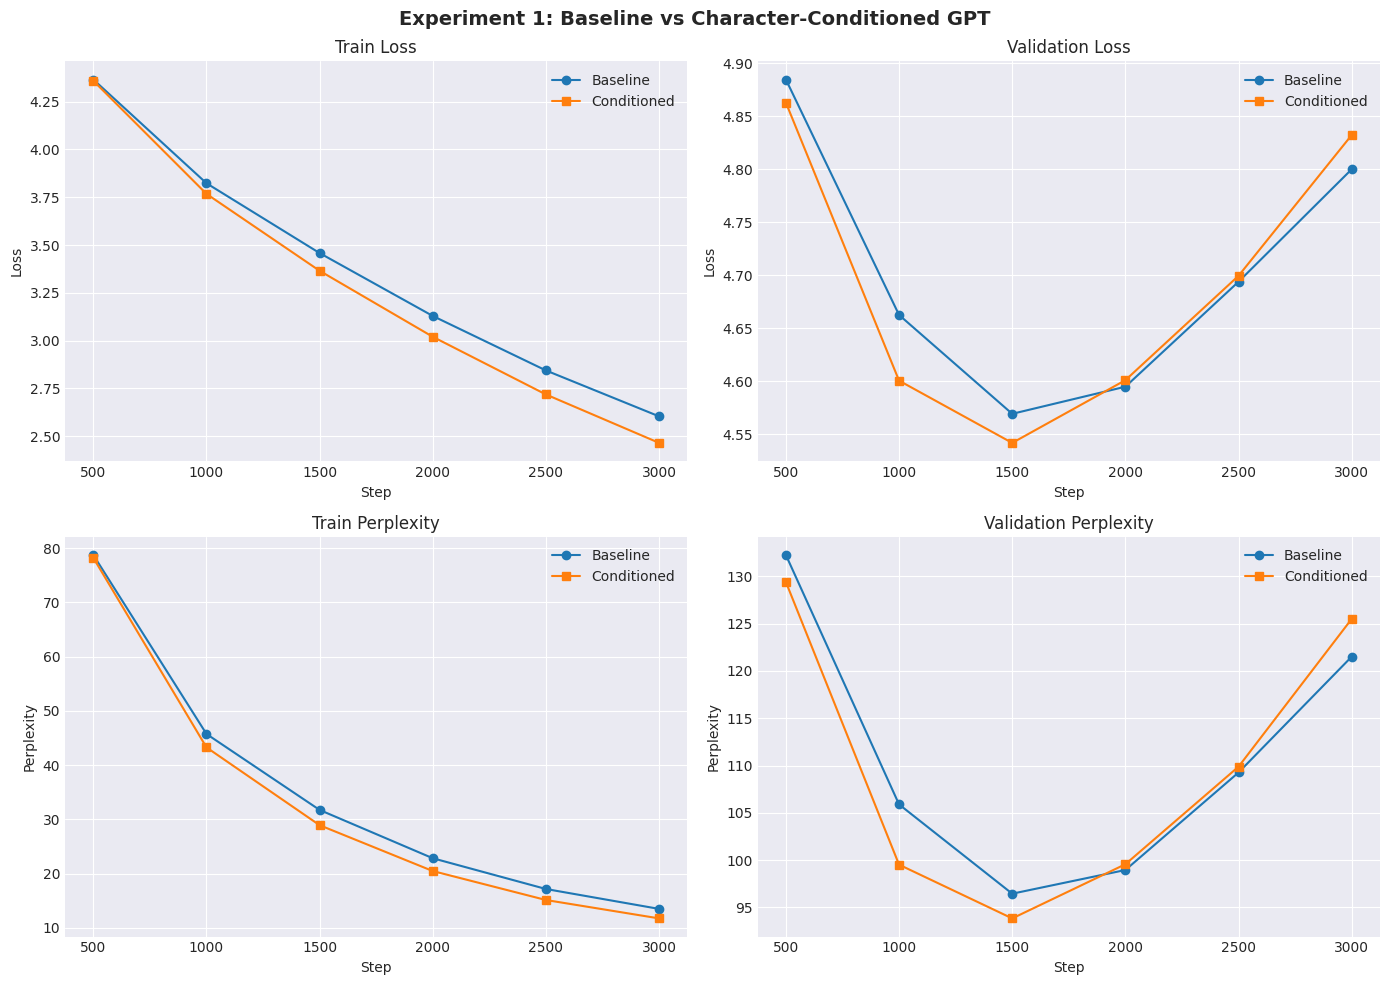

Saved: /projects/e32706/gwr4170/Text Generation/genre-story-generator/data/artifacts/model/experiment1_training_curves.png


In [30]:
bh = baseline_result["history"]
ch = conditioned_result["history"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, bvals, cvals, split, metric, ylabel in [
    (axes[0,0], bh["train_loss"], ch["train_loss"], "Train",      "loss",        "Loss"),
    (axes[0,1], bh["val_loss"],   ch["val_loss"],   "Validation", "loss",        "Loss"),
    (axes[1,0], bh["train_ppl"],  ch["train_ppl"],  "Train",      "perplexity",  "Perplexity"),
    (axes[1,1], bh["val_ppl"],    ch["val_ppl"],     "Validation", "perplexity",  "Perplexity"),
]:
    ax.plot(bh["step"], bvals, "o-", label="Baseline",    color="C0")
    ax.plot(ch["step"], cvals, "s-", label="Conditioned", color="C1")
    ax.set_xlabel("Step"); ax.set_ylabel(ylabel)
    ax.set_title(f"{split} {metric.capitalize()}")
    ax.legend()

fig.suptitle("Experiment 1: Baseline vs Character-Conditioned GPT", fontsize=14, fontweight="bold")
plt.tight_layout()
plot_path = CHECKPOINT_DIR / "experiment1_training_curves.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")


In [31]:
# Summary table
loss_delta = baseline_result["best_val_loss"] - conditioned_result["best_val_loss"]
ppl_delta  = baseline_result["best_val_ppl"]  - conditioned_result["best_val_ppl"]
loss_pct   = 100 * loss_delta / baseline_result["best_val_loss"]
ppl_pct    = 100 * ppl_delta  / baseline_result["best_val_ppl"]
direction  = "improvement" if loss_delta > 0 else "degradation"

summary_df = pd.DataFrame({
    "Metric": ["Total Params", "Speaker Emb Params", "Best Val Loss", "Best Val PPL",
               "Best Step", "Training Time (s)"],
    "Baseline GPT": [
        f"{baseline_params:,}", "0",
        f"{baseline_result['best_val_loss']:.4f}", f"{baseline_result['best_val_ppl']:.2f}",
        str(baseline_result["best_step"]), f"{baseline_result['elapsed_s']:.1f}",
    ],
    "Char-Conditioned GPT": [
        f"{conditioned_params:,}", f"{speaker_emb_params:,}",
        f"{conditioned_result['best_val_loss']:.4f}", f"{conditioned_result['best_val_ppl']:.2f}",
        str(conditioned_result["best_step"]), f"{conditioned_result['elapsed_s']:.1f}",
    ],
})
display(summary_df.style.set_caption("Experiment 1: Quantitative Summary").hide(axis="index"))

print(f"\nVal loss {direction}: {abs(loss_delta):.4f} ({abs(loss_pct):.2f}%)")
print(f"Val PPL  {direction}: {abs(ppl_delta):.2f}  ({abs(ppl_pct):.2f}%)")
print(f"\nNote: positive delta = conditioned wins; negative = baseline wins")


Metric,Baseline GPT,Char-Conditioned GPT
Total Params,"31,325,952","31,365,632"
Speaker Emb Params,0,"39,680"
Best Val Loss,4.5691,4.5416
Best Val PPL,96.46,93.84
Best Step,1500,1500
Training Time (s),174.9,176.3



Val loss improvement: 0.0275 (0.60%)
Val PPL  improvement: 2.61  (2.71%)

Note: positive delta = conditioned wins; negative = baseline wins


In [32]:
# Save JSON report
experiment_report = {
    "experiment": "character_embeddings_ablation",
    "config"    : {k: v for k, v in EXPERIMENT_CONFIG.items() if k != "betas"},
    "num_characters": num_characters,
    "baseline"  : {
        "params": baseline_params,
        "best_val_loss": baseline_result["best_val_loss"],
        "best_val_ppl" : baseline_result["best_val_ppl"],
        "best_step"    : baseline_result["best_step"],
        "elapsed_s"    : baseline_result["elapsed_s"],
    },
    "conditioned": {
        "params"            : conditioned_params,
        "speaker_emb_params": speaker_emb_params,
        "best_val_loss"     : conditioned_result["best_val_loss"],
        "best_val_ppl"      : conditioned_result["best_val_ppl"],
        "best_step"         : conditioned_result["best_step"],
        "elapsed_s"         : conditioned_result["elapsed_s"],
    },
    "delta": {
        "val_loss"  : round(loss_delta, 6),
        "val_ppl"   : round(ppl_delta, 4),
        "loss_pct"  : round(loss_pct, 4),
        "ppl_pct"   : round(ppl_pct, 4),
        "winner"    : "conditioned" if loss_delta > 0 else "baseline",
    },
}
report_path = CHECKPOINT_DIR / "experiment1_character_embeddings.json"
with open(report_path, "w") as f:
    json.dump(experiment_report, f, indent=2)
print(f"Saved: {report_path}")


Saved: /projects/e32706/gwr4170/Text Generation/genre-story-generator/data/artifacts/model/experiment1_character_embeddings.json


## 10. Per-Character Perplexity

Aggregate val loss is not enough — compute per-speaker perplexity to see which characters
benefit from conditioning and which are hurt (especially rare ones with sparse training data).


In [33]:
@torch.no_grad()
def per_character_perplexity(model, model_type, config, top_n=20):
    """
    Compute per-speaker val perplexity by running windows that start within
    each speaker's token range. Only characters with >= block_size val tokens
    get a reliable estimate.
    """
    model.eval()
    block_size = config["block_size"]
    results    = {}

    # Build speaker → list of token positions in val_ids
    speaker_positions = {}
    for pos, sid in enumerate(val_speaker_ids.tolist()):
        if sid == 0: continue
        speaker_positions.setdefault(sid, []).append(pos)

    for sid, positions in speaker_positions.items():
        if len(positions) < block_size:
            continue   # not enough data for a reliable estimate
        # Sample up to 50 non-overlapping windows starting at speaker positions
        valid_starts = [p for p in positions if p + block_size + 1 <= len(val_ids)]
        if not valid_starts: continue
        rng = np.random.default_rng(seed=42)
        chosen = rng.choice(valid_starts, size=min(50, len(valid_starts)), replace=False)

        losses = []
        for start in chosen:
            x = val_ids[start:start + block_size].unsqueeze(0).to(device)
            y = val_ids[start + 1:start + block_size + 1].unsqueeze(0).to(device)
            if model_type == "conditioned":
                s = val_speaker_ids[start:start + block_size].unsqueeze(0).to(device)
                _, loss = model(x, y, character_ids=s)
            else:
                _, loss = model(x, y)
            losses.append(loss.item())

        avg  = float(np.mean(losses))
        results[sid] = {"loss": avg, "ppl": math.exp(avg),
                        "n_windows": len(losses),
                        "speaker": id_to_speaker.get(sid, "?")}

    model.train()
    return results


print("Computing per-character perplexity (baseline)...")
baseline_per_char = per_character_perplexity(baseline_model, "baseline", EXPERIMENT_CONFIG)

print("Computing per-character perplexity (conditioned)...")
conditioned_per_char = per_character_perplexity(conditioned_model, "conditioned", EXPERIMENT_CONFIG)

# Merge into a comparison DataFrame
all_sids = sorted(set(baseline_per_char) | set(conditioned_per_char))
rows = []
for sid in all_sids:
    b = baseline_per_char.get(sid)
    c = conditioned_per_char.get(sid)
    if b is None or c is None: continue
    delta_ppl = b["ppl"] - c["ppl"]
    rows.append({
        "speaker"      : id_to_speaker.get(sid, "?"),
        "id"           : sid,
        "baseline_ppl" : round(b["ppl"], 2),
        "cond_ppl"     : round(c["ppl"], 2),
        "delta_ppl"    : round(delta_ppl, 2),    # positive = conditioned wins
        "n_windows"    : b["n_windows"],
    })

per_char_df = pd.DataFrame(rows).sort_values("delta_ppl", ascending=False)
print(f"\nPer-character PPL — top {min(20, len(per_char_df))} by conditioned benefit:")
display(per_char_df.head(20).style
        .background_gradient(subset=["delta_ppl"], cmap="RdYlGn")
        .hide(axis="index"))

print(f"\nBottom 10 (conditioned hurts most):")
display(per_char_df.tail(10).style
        .background_gradient(subset=["delta_ppl"], cmap="RdYlGn")
        .hide(axis="index"))


Computing per-character perplexity (baseline)...
Computing per-character perplexity (conditioned)...

Per-character PPL — top 10 by conditioned benefit:


speaker,id,baseline_ppl,cond_ppl,delta_ppl,n_windows
BIONDELLO,17,197.430000,174.420000,23.010000,50
BAPTISTA,13,109.140000,106.890000,2.250000,50
LUCENTIO,102,177.310000,176.340000,0.970000,50
KATHARINA,82,69.340000,70.770000,-1.430000,50
BIANCA,16,161.660000,164.290000,-2.630000,50
PETRUCHIO,121,98.450000,101.920000,-3.470000,50
TRANIO,145,97.030000,100.630000,-3.600000,50
HORTENSIO,77,91.030000,99.540000,-8.510000,50
GRUMIO,70,203.360000,218.490000,-15.130000,50
GREMIO,68,140.400000,168.790000,-28.390000,50



Bottom 10 (conditioned hurts most):


speaker,id,baseline_ppl,cond_ppl,delta_ppl,n_windows
BIONDELLO,17,197.430000,174.420000,23.010000,50
BAPTISTA,13,109.140000,106.890000,2.250000,50
LUCENTIO,102,177.310000,176.340000,0.970000,50
KATHARINA,82,69.340000,70.770000,-1.430000,50
BIANCA,16,161.660000,164.290000,-2.630000,50
PETRUCHIO,121,98.450000,101.920000,-3.470000,50
TRANIO,145,97.030000,100.630000,-3.600000,50
HORTENSIO,77,91.030000,99.540000,-8.510000,50
GRUMIO,70,203.360000,218.490000,-15.130000,50
GREMIO,68,140.400000,168.790000,-28.390000,50


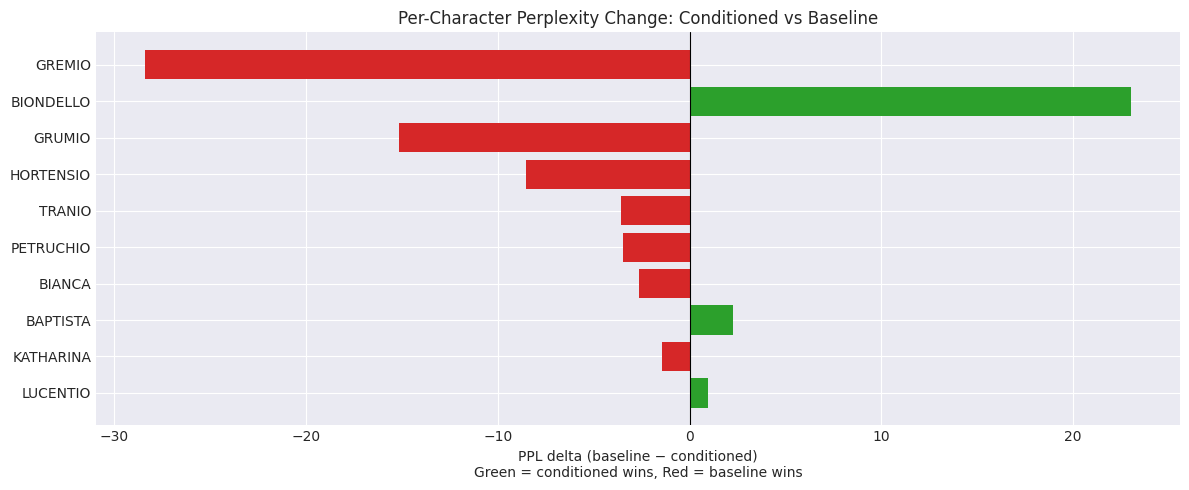

Saved: /projects/e32706/gwr4170/Text Generation/genre-story-generator/data/artifacts/model/experiment1_per_character_ppl.png


In [34]:
# Bar chart: top 20 characters by |delta_ppl|
top20 = per_char_df.reindex(per_char_df["delta_ppl"].abs().nlargest(20).index)
colors = ["#2ca02c" if d > 0 else "#d62728" for d in top20["delta_ppl"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top20["speaker"], top20["delta_ppl"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("PPL delta (baseline − conditioned)\nGreen = conditioned wins, Red = baseline wins")
ax.set_title("Per-Character Perplexity Change: Conditioned vs Baseline")
ax.invert_yaxis()
plt.tight_layout()
ppc_path = CHECKPOINT_DIR / "experiment1_per_character_ppl.png"
plt.savefig(ppc_path, dpi=150)
plt.show()
print(f"Saved: {ppc_path}")


## 11. Qualitative Evaluation

Generate from both models with identical prompts. Verify character IDs exist in training set
before generating — unknown IDs fall back to id=0 and get no useful conditioning signal.


In [35]:
EVAL_PROMPTS = ["ROMEO:", "JULIET:", "HAMLET:", "MACBETH:", "PROSPERO:"]
GEN_KWARGS   = dict(max_new_tokens=200, temperature=0.8, top_k=40, top_p=0.95)

# ── Load best checkpoints ─────────────────────────────────────────────────────
baseline_ckpt_data    = torch.load(baseline_ckpt,    map_location=device, weights_only=False)
conditioned_ckpt_data = torch.load(conditioned_ckpt, map_location=device, weights_only=False)

best_baseline = GPTBaseline(vocab_size, EXPERIMENT_CONFIG).to(device)
best_baseline.load_state_dict(baseline_ckpt_data["model"])
best_baseline.eval()

best_conditioned = GPTCharacterConditioned(vocab_size, num_characters, EXPERIMENT_CONFIG).to(device)
best_conditioned.load_state_dict(conditioned_ckpt_data["model"])
best_conditioned.eval()

print("Loaded best checkpoints.")
print(f"  Baseline    best step: {baseline_ckpt_data['extra']['best_step']}")
print(f"  Conditioned best step: {conditioned_ckpt_data['extra']['best_step']}")


Loaded best checkpoints.
  Baseline    best step: 1500
  Conditioned best step: 1500


In [36]:
print("=" * 80)
print("QUALITATIVE COMPARISON: Baseline vs Character-Conditioned")
print("=" * 80)

for prompt_text in EVAL_PROMPTS:
    speaker_name = prompt_text.rstrip(":")
    char_id      = speaker_to_id.get(speaker_name, 0)

    if char_id == 0:
        print(f"\n{'─'*80}")
        print(f"PROMPT: {prompt_text}  → speaker '{speaker_name}' NOT in training set (id=0); skipping.")
        continue

    prompt_ids = torch.tensor([encode(prompt_text)], dtype=torch.long, device=device)

    set_seed(EXPERIMENT_CONFIG["seed"])
    baseline_out   = best_baseline.generate(prompt_ids.clone(), **GEN_KWARGS)
    baseline_text  = decode(baseline_out[0].tolist())

    set_seed(EXPERIMENT_CONFIG["seed"])
    cond_out  = best_conditioned.generate(prompt_ids.clone(), character_id=char_id, **GEN_KWARGS)
    cond_text = decode(cond_out[0].tolist())

    print(f"\n{'─'*80}")
    print(f"PROMPT: {prompt_text}  (character_id={char_id}, speaker='{speaker_name}')")
    print(f"{'─'*80}")
    print(f"[BASELINE]:\n{baseline_text[:500]}")
    print(f"\n[CONDITIONED (id={char_id})]:\n{cond_text[:500]}")


QUALITATIVE COMPARISON: Baseline vs Character-Conditioned

────────────────────────────────────────────────────────────────────────────────
PROMPT: ROMEO:  (character_id=134, speaker='ROMEO')
────────────────────────────────────────────────────────────────────────────────
[BASELINE]:
ROMEO:
O, that is it is, and a man.

MERCUTIO:
Nay, a bawd, I know this?

ROMEO:
Away! O, I have a dream of my lady!
O, thou art thou art thou hast spoke.

ROMEO:
I pray thee, she must I didst be:
What wouldst thou art not.

BENVOLIO:
What hast thou wast thou?

MERCUTIO:
Away! a friar?

MERCUTIO:
Why, thou art a bawd.

MERCUTIO:
Why, what's a villain!
Nurse:
Come, thou art thou art not love'st:
Nurse:
Tranio, by a dost, is not so?

BENVOLIO:
O, I have I know's for she?

MERCUTIO:
If

[CONDITIONED (id=134)]:
ROMEO:
A word that is but a thousand times
That would have been been in a word,
For the county's head, and, and as well as you,
That's sake, like a vault, and yet I'll stay
That is here to my soul, and 

## 12. Speaker Embedding Analysis

Visualize speaker embedding similarity to validate that the model has learned
a meaningful character space. If working correctly, characters from the same play
or with similar roles should cluster together.


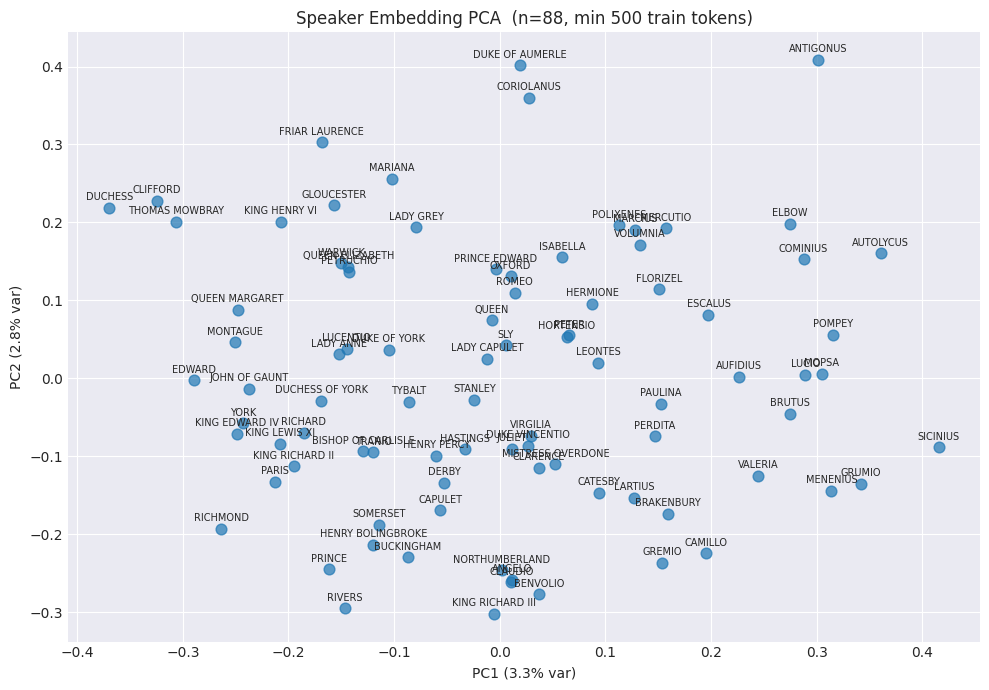

Saved: /projects/e32706/gwr4170/Text Generation/genre-story-generator/data/artifacts/model/experiment1_speaker_emb_pca.png
Explained variance: PC1=0.033  PC2=0.028

If embeddings are random-looking → conditioning may not have learned character structure.
If clustered by character affinity → conditioning signal was informative.


In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# Extract speaker embeddings for all known characters
best_conditioned.eval()
with torch.no_grad():
    all_embs = best_conditioned.speaker_embedding.weight.cpu().numpy()  # (num_characters, d_model)

# Only plot characters with enough training data (>= 500 tokens)
min_tokens = 500
eligible   = {sid: id_to_speaker[sid] for sid, cnt in train_speaker_counts.most_common()
              if cnt >= min_tokens and sid > 0}

if len(eligible) < 3:
    print("Too few eligible speakers for PCA — lower min_tokens or check data.")
else:
    sids     = list(eligible.keys())
    names    = [eligible[s] for s in sids]
    embs_sub = normalize(all_embs[sids])          # L2-normalize before PCA

    n_components = min(2, len(sids) - 1)
    pca   = PCA(n_components=n_components, random_state=42)
    coords = pca.fit_transform(embs_sub)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(coords[:, 0], coords[:, 1], s=60, alpha=0.7)
    for i, name in enumerate(names):
        ax.annotate(name, (coords[i, 0], coords[i, 1]),
                    fontsize=7, ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    ax.set_title(f"Speaker Embedding PCA  (n={len(sids)}, min {min_tokens} train tokens)")
    plt.tight_layout()
    emb_path = CHECKPOINT_DIR / "experiment1_speaker_emb_pca.png"
    plt.savefig(emb_path, dpi=150)
    plt.show()
    print(f"Saved: {emb_path}")
    print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}  PC2={pca.explained_variance_ratio_[1]:.3f}")
    print("\nIf embeddings are random-looking → conditioning may not have learned character structure.")
    print("If clustered by character affinity → conditioning signal was informative.")


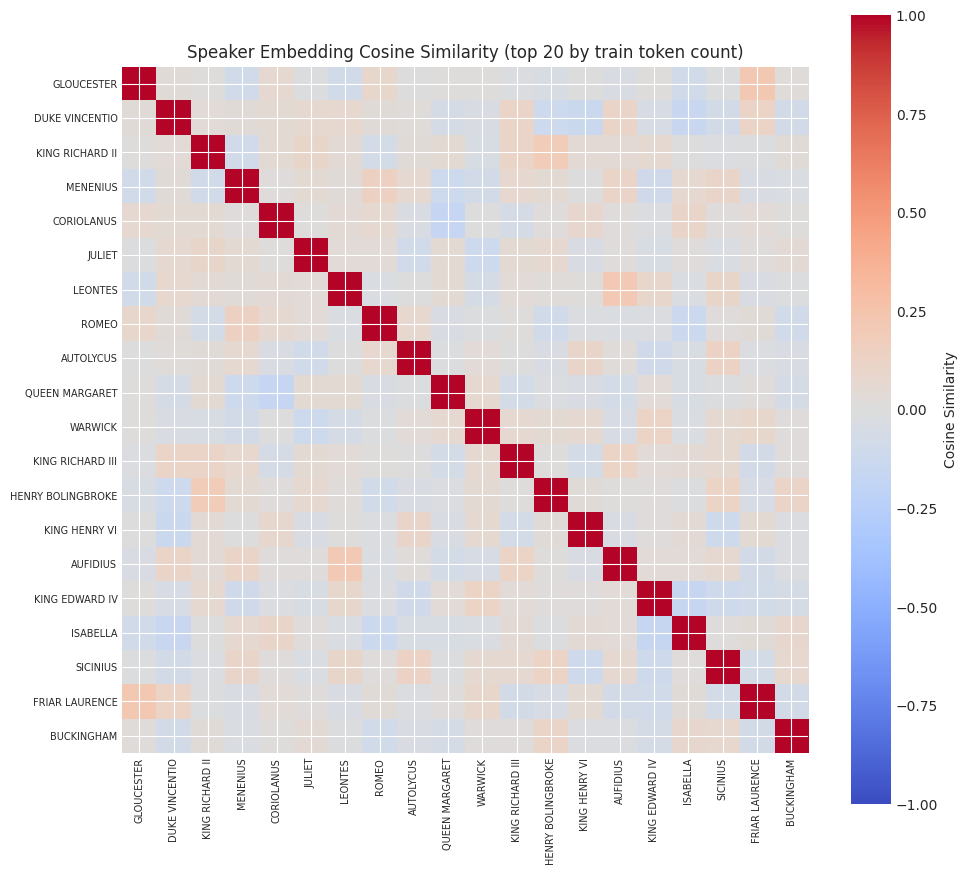

Saved: /projects/e32706/gwr4170/Text Generation/genre-story-generator/data/artifacts/model/experiment1_speaker_emb_heatmap.png


In [38]:
# Cosine similarity heatmap for top-N speakers
top_n = min(20, len(eligible))
top_sids  = [s for s, _ in train_speaker_counts.most_common() if s in eligible][:top_n]
top_names = [id_to_speaker[s] for s in top_sids]
embs_top  = normalize(all_embs[top_sids])

sim_matrix = embs_top @ embs_top.T   # cosine sim (already L2-normalized)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(sim_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(top_n)); ax.set_xticklabels(top_names, rotation=90, fontsize=7)
ax.set_yticks(range(top_n)); ax.set_yticklabels(top_names, fontsize=7)
plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title(f"Speaker Embedding Cosine Similarity (top {top_n} by train token count)")
plt.tight_layout()
hmap_path = CHECKPOINT_DIR / "experiment1_speaker_emb_heatmap.png"
plt.savefig(hmap_path, dpi=150)
plt.show()
print(f"Saved: {hmap_path}")


## 13. Analysis and Conclusions

### Research Question
Does adding `speaker_embedding = nn.Embedding(num_characters, d_model)` to a decoder-only GPT
improve character-specific text generation on TinyShakespeare?

### What to look for in results

**Quantitative (Section 9)**
- Val loss / PPL delta: even a 0.01–0.05 nats improvement is meaningful given the small overhead
- If conditioned wins: speaker identity is a useful inductive bias
- If baseline wins or ties: the model can already infer speaker from the `SPEAKER:\n` prefix tokens alone

**Per-character PPL (Section 10)**
- Major characters (ROMEO, JULIET, etc.) with rich training data should benefit most
- Minor characters with sparse data may get worse — the embedding can't generalize
- High variance across characters → conditioning helps selectively, not globally

**Embedding geometry (Section 12)**
- Random-looking PCA / flat similarity matrix → conditioning didn't learn character structure
- Meaningful clustering → the gradient signal was strong enough to differentiate speakers

### Known limitations

- **Sparse speakers**: random window sampling under-represents rare characters; per-char PPL estimates for low-frequency speakers have high variance
- **Single ID broadcast**: `generate()` broadcasts one `character_id` across the full context, injecting conflicting signal when the prompt belongs to a different speaker
- **Val unknown leakage**: val tokens with `speaker_id=0` degrade conditioned model's val loss signal (see Section 3 coverage stats)
- **No cross-character generation**: the experiment evaluates single-character conditioning, not multi-turn dialogue with switching speakers

### Next steps

- **Learned speaker tokens**: prepend a special `<SPEAKER_NAME>` token to each turn instead of a broadcast embedding
- **Per-turn conditioning**: switch `character_id` at turn boundaries during both training and generation
- **Attention analysis**: visualize which positions the model attends to differently when conditioned
- **Scale**: does the effect hold or amplify with larger models / more training steps?
